In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
DATA_PATH = Path("../data/raw/ml-100k")

ratings = pd.read_csv(
    DATA_PATH / "u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

train, test = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

In [5]:
train_matrix = train.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

train_matrix.shape

matrix_filled = train_matrix.fillna(0)

In [6]:
user_similarity = cosine_similarity(matrix_filled)

user_similarity = pd.DataFrame(
    user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

user_similarity.iloc[:5, :5]

user_id,1,2,3,4,5
user_id,,,,,
1,1.000000,0.136196,0.030424,0.026203,0.284613
2,0.136196,1.000000,0.114644,0.168220,0.093128
3,0.030424,0.114644,1.000000,0.346894,0.000000
4,0.026203,0.168220,0.346894,1.000000,0.011848
5,0.284613,0.093128,0.000000,0.011848,1.000000


In [7]:
user_id = 1

similar_users = (
    user_similarity.loc[user_id]
    .drop(user_id)
    .sort_values(ascending=False)
    .head(10)
)

similar_users

user_id
514    0.458971
268    0.444627
293    0.441341
457    0.438585
435    0.433103
916    0.427880
429    0.426171
738    0.424145
727    0.421395
303    0.419184
Name: 1, dtype: float64

In [8]:
def predict_rating(user_id, movie_id, k=20):
    if user_id not in user_similarity.index:
        return train["rating"].mean()

    if movie_id not in train_matrix.columns:
        return train["rating"].mean()

    movie_ratings = train_matrix[movie_id].dropna()

    if len(movie_ratings) == 0:
        return train["rating"].mean()

    similarities = user_similarity.loc[user_id, movie_ratings.index]

    top_users = similarities.sort_values(
        ascending=False
    ).head(k)

    ratings = movie_ratings.loc[top_users.index]

    if top_users.sum() == 0:
        return train["rating"].mean()

    prediction = np.dot(
        top_users.values,
        ratings.values
    ) / top_users.sum()

    return prediction

In [9]:
example = test.iloc[0]

example

user_id            877
movie_id           381
rating               4
timestamp    882677345
Name: 75721, dtype: int64

In [10]:
predicted = predict_rating(
    example["user_id"],
    example["movie_id"]
)

print("User:", example["user_id"])
print("Movie:", example["movie_id"])
print("Actual rating:", example["rating"])
print("Predicted rating:", round(predicted, 2))

User: 877
Movie: 381
Actual rating: 4
Predicted rating: 3.49


In [11]:
cf_predictions = []

for row in test.itertuples():
    prediction = predict_rating(
        row.user_id,
        row.movie_id,
        k=20
    )

    cf_predictions.append(prediction)

In [12]:
cf_rmse = np.sqrt(
    mean_squared_error(
        test["rating"],
        cf_predictions
    )
)

cf_mae = mean_absolute_error(
    test["rating"],
    cf_predictions
)

print(f"Collaborative Filtering RMSE: {cf_rmse:.4f}")
print(f"Collaborative Filtering MAE:  {cf_mae:.4f}")

Collaborative Filtering RMSE: 1.0118
Collaborative Filtering MAE:  0.8028


In [13]:
k_values = [5, 10, 20, 30, 50]

results = []

for k in k_values:

    predictions = []

    for row in test.itertuples():
        prediction = predict_rating(
            row.user_id,
            row.movie_id,
            k=k
        )

        predictions.append(prediction)

    rmse = np.sqrt(
        mean_squared_error(
            test["rating"],
            predictions
        )
    )

    mae = mean_absolute_error(
        test["rating"],
        predictions
    )

    results.append({
        "k": k,
        "RMSE": rmse,
        "MAE": mae
    })

cf_results = pd.DataFrame(results)

cf_results

,k,RMSE,MAE
0,5,1.061975,0.842034
1,10,1.026200,0.815149
2,20,1.011828,0.802816
3,30,1.009017,0.800385
4,50,1.009840,0.801023


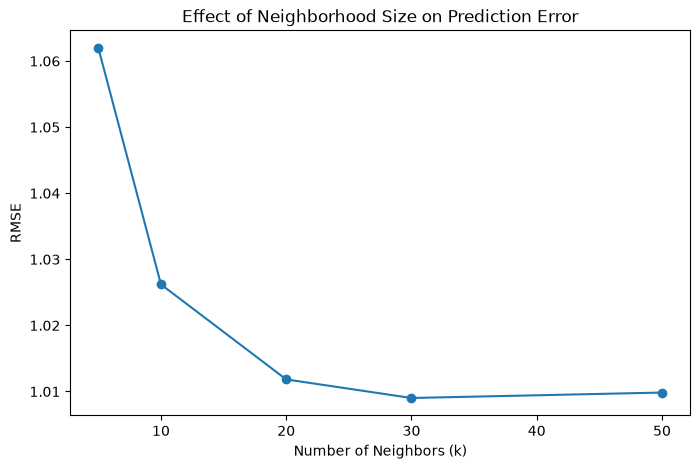

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    cf_results["k"],
    cf_results["RMSE"],
    marker="o"
)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("RMSE")
plt.title("Effect of Neighborhood Size on Prediction Error")

plt.show()

In [17]:
user_means = train.groupby("user_id")["rating"].mean()

centered_matrix = train_matrix.copy()

for user_id in centered_matrix.index:
    centered_matrix.loc[user_id] = (
        centered_matrix.loc[user_id]
        - user_means[user_id]
    )

centered_filled = centered_matrix.fillna(0)

In [18]:
centered_similarity = cosine_similarity(
    centered_filled
)

centered_similarity = pd.DataFrame(
    centered_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

In [19]:
def predict_centered_rating(user_id, movie_id, k=30):

    global_mean = train["rating"].mean()

    if user_id not in centered_similarity.index:
        return global_mean

    if movie_id not in train_matrix.columns:
        return user_means.get(user_id, global_mean)

    movie_ratings = train_matrix[movie_id].dropna()

    if len(movie_ratings) == 0:
        return user_means.get(user_id, global_mean)

    similarities = centered_similarity.loc[
        user_id,
        movie_ratings.index
    ]

    top_users = similarities.abs().sort_values(
        ascending=False
    ).head(k).index

    top_similarities = similarities.loc[top_users]

    neighbor_ratings = movie_ratings.loc[top_users]

    neighbor_means = user_means.loc[top_users]

    deviations = neighbor_ratings - neighbor_means

    denominator = np.abs(top_similarities).sum()

    if denominator == 0:
        return user_means.get(user_id, global_mean)

    prediction = (
        user_means[user_id]
        + np.dot(
            top_similarities.values,
            deviations.values
        ) / denominator
    )

    return np.clip(prediction, 1, 5)

In [20]:
centered_predictions = []

for row in test.itertuples():

    prediction = predict_centered_rating(
        row.user_id,
        row.movie_id,
        k=30
    )

    centered_predictions.append(prediction)

In [21]:
centered_rmse = np.sqrt(
    mean_squared_error(
        test["rating"],
        centered_predictions
    )
)

centered_mae = mean_absolute_error(
    test["rating"],
    centered_predictions
)

print(
    f"Mean-Centered CF RMSE: {centered_rmse:.4f}"
)

print(
    f"Mean-Centered CF MAE: {centered_mae:.4f}"
)

Mean-Centered CF RMSE: 0.9321
Mean-Centered CF MAE: 0.7289


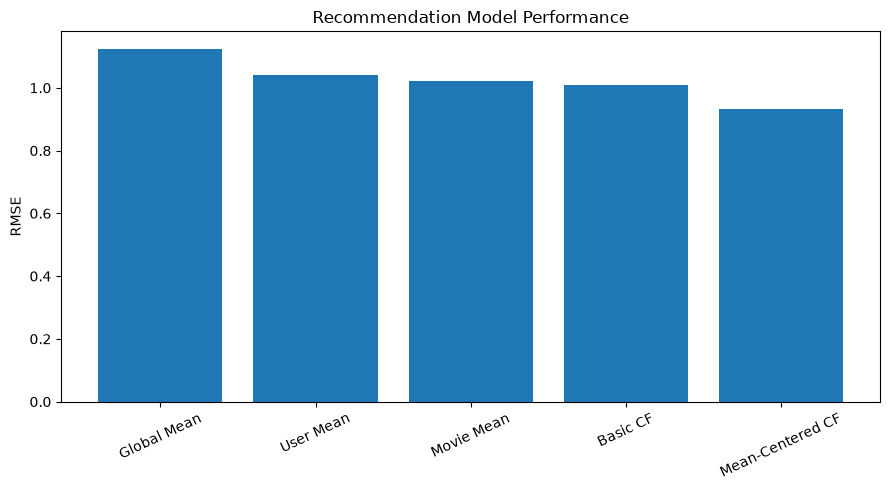

In [22]:
model_names = [
    "Global Mean",
    "User Mean",
    "Movie Mean",
    "Basic CF",
    "Mean-Centered CF"
]

rmse_values = [
    1.123860,
    1.041745,
    1.020964,
    1.009017,
    centered_rmse
]

plt.figure(figsize=(9, 5))

plt.bar(model_names, rmse_values)

plt.ylabel("RMSE")
plt.title("Recommendation Model Performance")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

## Collaborative Filtering Results

Basic user-based collaborative filtering improved upon the simple baseline models, with the best neighborhood size of k=30 achieving an RMSE of approximately 1.009.

Mean-centering user ratings produced a substantially larger improvement, reducing RMSE to approximately 0.932 and MAE to 0.729. This suggests that differences in how individual users use the rating scale are important when measuring user similarity.

Rather than comparing absolute ratings, mean-centered collaborative filtering measures whether users tend to like or dislike the same movies relative to their typical rating behavior.

Increasing the number of neighbors improved the basic collaborative filtering model up to approximately k=30, after which performance stopped improving. This illustrates the tradeoff between incorporating additional information and including increasingly dissimilar users.